In [2]:
import pandas as pd
from pathlib import Path

In [3]:
data_path = Path('./data/healthcare_dataset.csv')

In [4]:
healthcare_df = pd.read_csv(data_path)

In [5]:
healthcare_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
healthcare_df['Date of Admission'] = pd.to_datetime(healthcare_df['Date of Admission'])
healthcare_df['Discharge Date'] = pd.to_datetime(healthcare_df['Discharge Date'])

#create new feature
healthcare_df['Length of Stay'] = (healthcare_df['Discharge Date'] - healthcare_df['Date of Admission']).dt.days

In [7]:
healthcare_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [8]:
#drop duplicates
dedup_healthcare = healthcare_df.drop_duplicates()

In [9]:
dedup_healthcare.nunique()

Name                  49992
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Room Number             400
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
Length of Stay           30
dtype: int64

In [10]:
#TODO later - look at eXploring predicivitivesness of features (eX: is insurance provider more important than doctor/hospital - how does this line up with tanya's eXperience)

In [11]:
healthcare_encoded = pd.get_dummies(dedup_healthcare, columns=['Gender', 'Blood Type', 'Medical Condition','Insurance Provider','Admission Type','Medication','Test Results'], dtype=int)

In [12]:
healthcare_encoded.head()

,Name,Age,Date of Admission,Doctor,Hospital,Billing Amount,Room Number,Discharge Date,Length of Stay,Gender_Female,...,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Abnormal,Test Results_Inconclusive,Test Results_Normal
0,Bobby JacksOn,30,2024-01-31,Matthew Smith,Sons and Miller,18856.281306,328,2024-02-02,2,0,...,0,1,0,0,0,1,0,0,0,1
1,LesLie TErRy,62,2019-08-20,Samantha Davies,Kim Inc,33643.327287,265,2019-08-26,6,0,...,1,0,0,1,0,0,0,0,1,0
2,DaNnY sMitH,76,2022-09-22,Tiffany Mitchell,Cook PLC,27955.096079,205,2022-10-07,15,1,...,1,0,1,0,0,0,0,0,0,1
3,andrEw waTtS,28,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",37909.782410,450,2020-12-18,30,1,...,0,0,0,1,0,0,0,1,0,0
4,adrIENNE bEll,43,2022-09-19,Kathleen Hanna,White-White,14238.317814,458,2022-10-09,20,1,...,0,1,0,0,0,0,1,1,0,0


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split



In [15]:
print(healthcare_encoded.info())
print(healthcare_encoded.describe())
healthcare_encoded.to_csv('healthcare_encoded.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Name                                 54966 non-null  object        
 1   Age                                  54966 non-null  int64         
 2   Date of Admission                    54966 non-null  datetime64[ns]
 3   Doctor                               54966 non-null  object        
 4   Hospital                             54966 non-null  object        
 5   Billing Amount                       54966 non-null  float64       
 6   Room Number                          54966 non-null  int64         
 7   Discharge Date                       54966 non-null  datetime64[ns]
 8   Length of Stay                       54966 non-null  int64         
 9   Gender_Female                        54966 non-null  int64         
 10  Gender_Male    

In [17]:
column_names = healthcare_encoded.columns.tolist()


In [19]:
column_names


['Name',
 'Age',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Billing Amount',
 'Room Number',
 'Discharge Date',
 'Length of Stay',
 'Gender_Female',
 'Gender_Male',
 'Blood Type_A+',
 'Blood Type_A-',
 'Blood Type_AB+',
 'Blood Type_AB-',
 'Blood Type_B+',
 'Blood Type_B-',
 'Blood Type_O+',
 'Blood Type_O-',
 'Medical Condition_Arthritis',
 'Medical Condition_Asthma',
 'Medical Condition_Cancer',
 'Medical Condition_Diabetes',
 'Medical Condition_Hypertension',
 'Medical Condition_Obesity',
 'Insurance Provider_Aetna',
 'Insurance Provider_Blue Cross',
 'Insurance Provider_Cigna',
 'Insurance Provider_Medicare',
 'Insurance Provider_UnitedHealthcare',
 'Admission Type_Elective',
 'Admission Type_Emergency',
 'Admission Type_Urgent',
 'Medication_Aspirin',
 'Medication_Ibuprofen',
 'Medication_Lipitor',
 'Medication_Paracetamol',
 'Medication_Penicillin',
 'Test Results_Abnormal',
 'Test Results_Inconclusive',
 'Test Results_Normal']

In [23]:
column_names = healthcare_encoded.columns.tolist()
remove_columns = ['Name', 'Doctor', 'Date of Admission', 'Discharge Date', 'Hospital', 'Room Number','Length of Stay']
for column in remove_columns:
    print(column)
    column_names.remove(column)
    
    
column_names
   

Name
Doctor
Date of Admission
Discharge Date
Hospital
Room Number
Length of Stay


['Age',
 'Billing Amount',
 'Gender_Female',
 'Gender_Male',
 'Blood Type_A+',
 'Blood Type_A-',
 'Blood Type_AB+',
 'Blood Type_AB-',
 'Blood Type_B+',
 'Blood Type_B-',
 'Blood Type_O+',
 'Blood Type_O-',
 'Medical Condition_Arthritis',
 'Medical Condition_Asthma',
 'Medical Condition_Cancer',
 'Medical Condition_Diabetes',
 'Medical Condition_Hypertension',
 'Medical Condition_Obesity',
 'Insurance Provider_Aetna',
 'Insurance Provider_Blue Cross',
 'Insurance Provider_Cigna',
 'Insurance Provider_Medicare',
 'Insurance Provider_UnitedHealthcare',
 'Admission Type_Elective',
 'Admission Type_Emergency',
 'Admission Type_Urgent',
 'Medication_Aspirin',
 'Medication_Ibuprofen',
 'Medication_Lipitor',
 'Medication_Paracetamol',
 'Medication_Penicillin',
 'Test Results_Abnormal',
 'Test Results_Inconclusive',
 'Test Results_Normal']

In [24]:
## get dependent and target variables

X = healthcare_encoded[column_names]
y = healthcare_encoded['Length of Stay']

print(column_names)

['Age', 'Billing Amount', 'Gender_Female', 'Gender_Male', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis', 'Medical Condition_Asthma', 'Medical Condition_Cancer', 'Medical Condition_Diabetes', 'Medical Condition_Hypertension', 'Medical Condition_Obesity', 'Insurance Provider_Aetna', 'Insurance Provider_Blue Cross', 'Insurance Provider_Cigna', 'Insurance Provider_Medicare', 'Insurance Provider_UnitedHealthcare', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor', 'Medication_Paracetamol', 'Medication_Penicillin', 'Test Results_Abnormal', 'Test Results_Inconclusive', 'Test Results_Normal']


In [25]:
## split data into training and testing sets 
   # Percentage of data to be used for training (e.g., 80%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Random state for reproducibility

print("Training set size:", len(y_train))
print("Testing set size:", len(y_test))

# Check the shape of your training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Training set size: 43972
Testing set size: 10994
X_train shape: (43972, 34)
y_train shape: (43972,)
X_test shape: (10994, 34)
y_test shape: (10994,)


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [27]:
# Fit a Linear Regression model to the training data
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
# prediction 
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 75.18
Coefficient of determination: -0.00


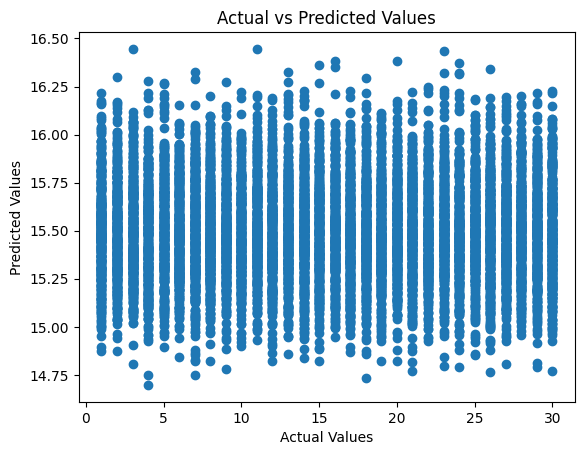

In [31]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()


In [43]:
X_train_plot = X_train.to_numpy()
X_train_plot= X_train_plot[:,1]


In [44]:
X_train_plot.shape

(43972,)

In [47]:
X_test_plot= X_test.to_numpy()
X_test_plot= X_test_plot[:,1]

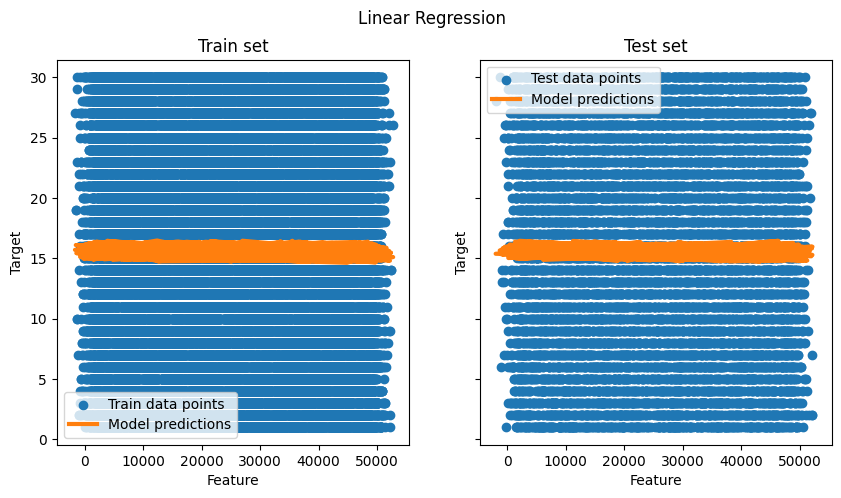

In [48]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train_plot, y_train, label="Train data points")
ax[0].plot(
    X_train_plot,
    model.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test_plot, y_test, label="Test data points")
ax[1].plot(X_test_plot, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()
fig.suptitle("Linear Regression")
plt.show()